# Vortex Induced Vibrations


In [319]:
import numpy as np
import matplotlib.pyplot as plt


L = 50.0
D = 0.5
rho_w = 1025
rho_c = 7880
T = 30000
b = 126
St = 0.21
dt = 0.005
t_end = 200

A_cross = np.pi * D**2 / 4
m = rho_c * A_cross * L
m_a = rho_w * A_cross * L
m_eff = m + m_a

epsilon = 0.3
A_coupling = 12.0
Cx0_hat = 1.0
Cy1_hat = 0.3
q1_hat = 1.0


In [320]:
def rhs(t, x, U):

    q = x[0]
    q_dot = x[1]
    y = x[2]
    y_dot = x[3]

    hydro_force= (rho_w * D**2 * L) / (m_eff * 8 * np.pi**2 * St**2) 
    
    nonlinear_term = (-2 * np.pi * St * y_dot * Cx0_hat + Cy1_hat * q1_hat * q)

    F = hydro_force * (U**2) * nonlinear_term * np.sqrt(1 + 4 * np.pi**2 * St**2 * y_dot**2)

    y_ddot = -2*zeta*Omega_n*y_dot - Omega_n**2*y + F

    q_ddot = -epsilon*(q**2 - 1)*q_dot - q + A_coupling * y_ddot

    return np.array([q_dot, q_ddot, y_dot, y_ddot])

In [321]:
def rk4(f, t, x, dt, U):

    k1 = f(t, x, U)
    k2 = f(t + dt/2, x + dt/2 * k1, U)
    k3 = f(t + dt/2, x + dt/2 * k2, U)
    k4 = f(t + dt, x + dt * k3, U)

    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

In [322]:
def comp_x(dt, t_end, U):
    time = np.arange(0, t_end, dt)
    x = np.array([0.01, 0.0, 0.0, 0.0])
    solution = np.zeros((len(time), 4))

    for i, t in enumerate(time):
        solution[i] = x
        x = rk4(rhs, t, x, dt, U)
    
    print(x)

    return time, solution

In [323]:
def simulate_velocity(dt, t_end, U):
    time = np.arange(0, t_end, dt)

    x = np.array([0.01, 0.0, 0.0, 0.0])

    y_history = []
    time , solution = comp_x(dt ,t_end ,U)
    
    for t in time:
        y_history.append(x[2])
        x = rk4(rhs, t, x, dt, U)

    y_history = np.array(y_history)

    cutoff = int(0.7 * len(solution))
    y_steady = y_history[cutoff:]

    amplitude = 0.5 * (np.max(y_steady) - np.min(y_steady))

    return amplitude

[-1.03789902e+00  1.49763483e+00  1.51474023e-05 -2.46006498e-05]
[-1.03789902e+00  1.49763483e+00  1.51474023e-05 -2.46006498e-05]
Amplitude for U=0.03 m/s: 0.03 mm
Time taken for U=0.03 m/s: 2.24 seconds
[-1.19598521e+00  1.38611790e+00  1.29874033e-04 -1.65684934e-04]
[-1.19598521e+00  1.38611790e+00  1.29874033e-04 -1.65684934e-04]
Amplitude for U=0.09 m/s: 0.21 mm
Time taken for U=0.09 m/s: 2.27 seconds
[-1.47706982e+00  1.15577104e+00  4.46799366e-04 -3.69015562e-04]
[-1.47706982e+00  1.15577104e+00  4.46799366e-04 -3.69015562e-04]
Amplitude for U=0.15 m/s: 0.59 mm
Time taken for U=0.15 m/s: 2.19 seconds
[-1.79945831e+00  7.72323414e-01  1.04822437e-03 -4.15935175e-04]
[-1.79945831e+00  7.72323414e-01  1.04822437e-03 -4.15935175e-04]
Amplitude for U=0.21 m/s: 1.15 mm
Time taken for U=0.21 m/s: 2.20 seconds
[-1.99952005e+00  7.91074286e-02  1.90865073e-03  1.03091962e-04]
[-1.99952005e+00  7.91074286e-02  1.90865073e-03  1.03091962e-04]
Amplitude for U=0.27 m/s: 1.92 mm
Time taken

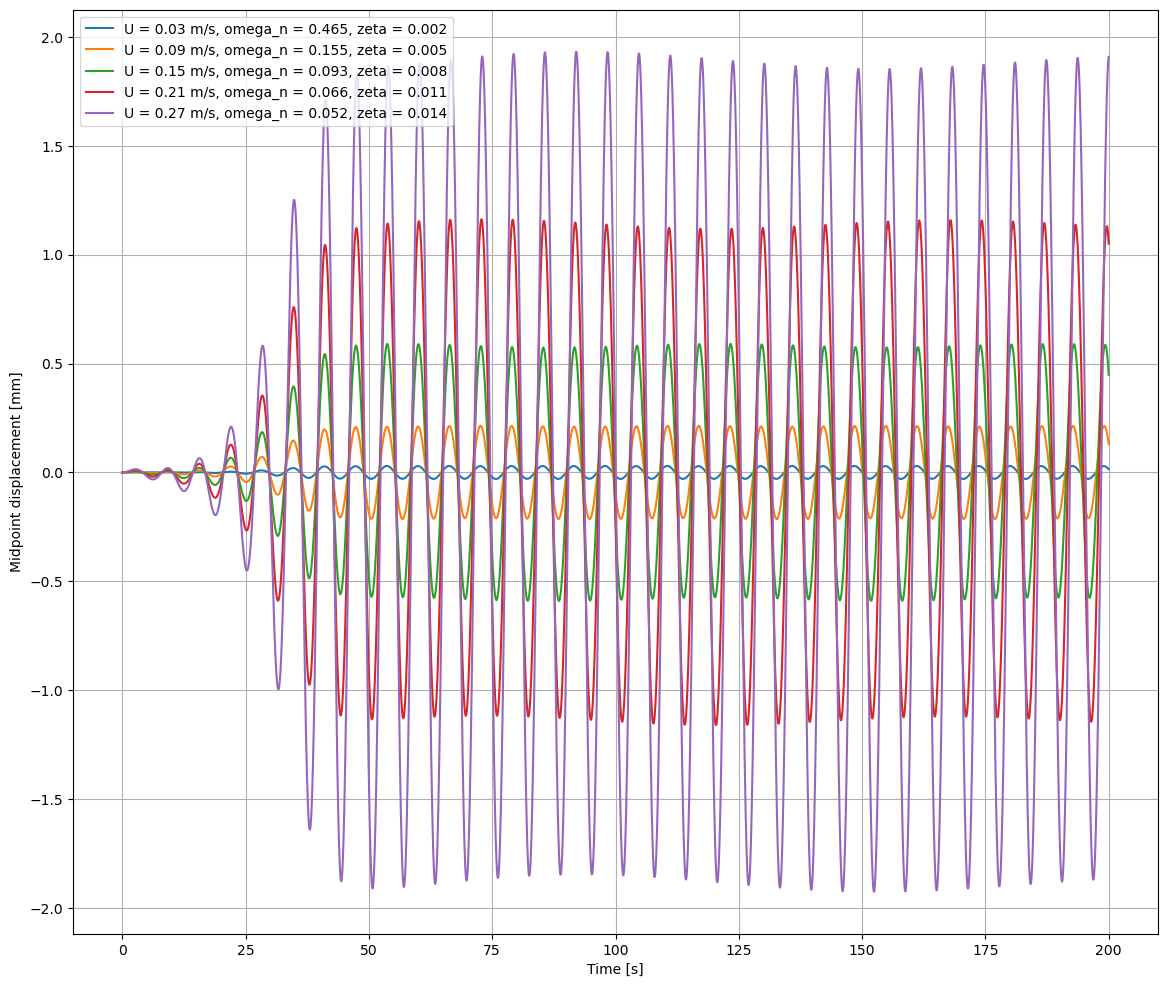

In [324]:
U_range = np.linspace(0.03, 0.27, 5)

plt.figure(figsize=(14,12))
import time as td
start_time = td.time()

for U in U_range:
    omega_s = 2 * np.pi * St * U / D
    Omega_n = ((np.pi / L) * np.sqrt(T / m_eff)) / omega_s
    zeta = b / (2 *Omega_n* m_eff)
    start_time = td.time()
    time, solution = comp_x(dt, t_end, U)
    plt.plot(time, 1000* solution[:,2], label=f"U = {U:.2f} m/s, omega_n = {Omega_n:.3f}, zeta = {zeta:.3f}")
    print(f"Amplitude for U={U:.2f} m/s: {simulate_velocity(dt, t_end, U)*1000:.2f} mm")
    end_time = td.time()
    print(f"Time taken for U={U:.2f} m/s: {end_time - start_time:.2f} seconds")


plt.xlabel("Time [s]")
plt.ylabel("Midpoint displacement [mm]")
plt.legend()
plt.grid()